# Model 1: From Scratch DCNN
Designed by: Theo Negrao

A small VGG-style CNN trained from scratch.

### Iterations
- Replace Flatten() with GlobalAveragePooling2D()
  - performance before: Test acc = 0.736, macro F1 = 0.704
  - performance after: Test acc = 0.618, macro F1 = 0.562
- Cap class weights at 2.0
  - performance before:
  - performance after:
- Lower Adam learning rate to 3e-4
  - performance before:
  - performance after:

In [1]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sys.path.append("..")
from shared_utils import (
    PROJECT_ROOT,
    load_data,
    eval_model,
    save_metrics,
    plot_training_history,
    get_class_weights,
)

2026-05-28 13:00:41.979133: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779973241.992875   76391 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779973241.997041   76391 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779973242.008923   76391 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779973242.008942   76391 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779973242.008945   76391 computation_placer.cc:177] computation placer alr

In [2]:
# Configurations

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# Directory to save figures
FIGURES_DIR = PROJECT_ROOT / "scratch_cnn" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Data Loading
data = load_data()

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

train_labels = data["train_labels"]
val_labels = data["val_labels"]
test_labels = data["test_labels"]

class_list = data["class_list"]
NUM_CLASSES = len(class_list)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Classes:", class_list)

print()
print("Example train image:")
print(train_paths[0])
print("Exists:", Path(train_paths[0]).exists())

Train: 10859
Val: 2328
Test: 2328
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Example train image:
/home/n11902736/cab420/WasteClassification/data/garbage_classification/clothes/clothes3810.jpg
Exists: True


## Data Preprocessing
2 datasets created:
 - train_ds = shuffled, augmented during training
 - train_eval_ds = not shuffled, used only for train-set predictions/evaluation

Preprocessing:
 - resize to 128x128
 - normalize to [0,1]
 - augmentations:
    - Horizontal Flip
    - Rotation
    - Zoom
    - Translation

In [4]:
# Image loading settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1779973244.345675   76391 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:04:0b.0, compute capability: 8.6


Datasets created.


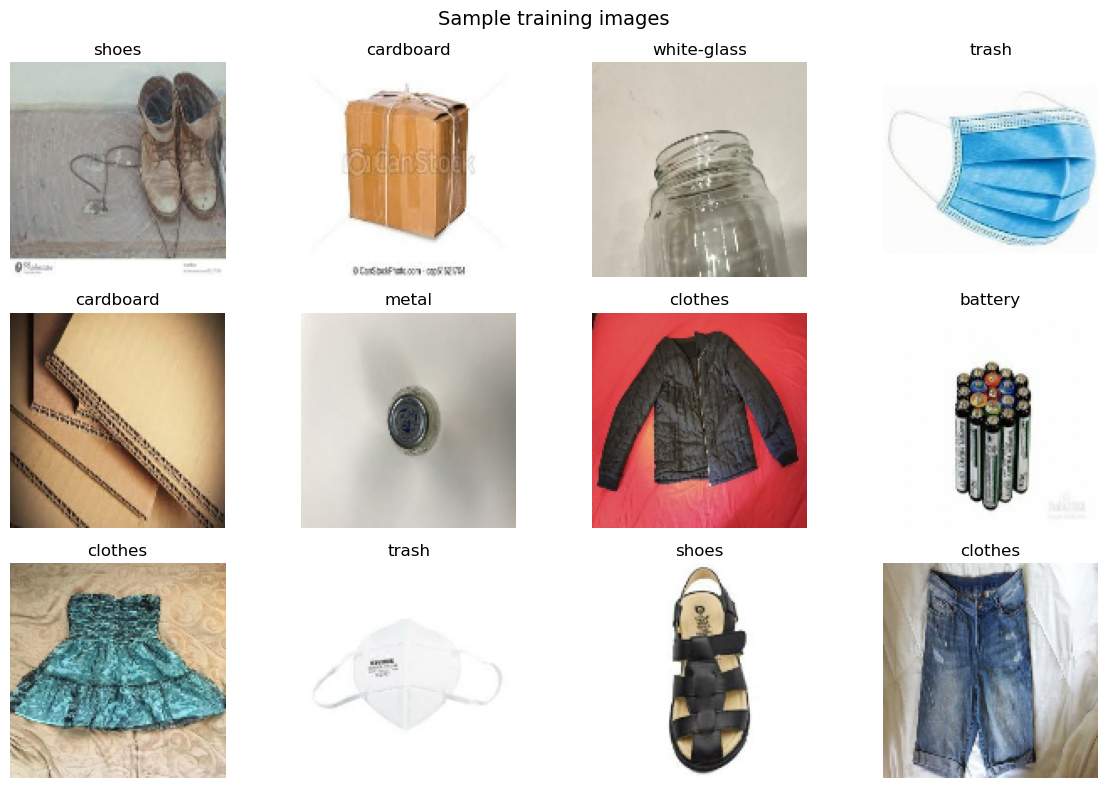

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/sample_training_images.png


In [5]:
def load_image(path, label):
    """
    Load one image file and return image tensor plus label.

    Images are:
    - decoded as RGB
    - resized to IMG_SIZE
    - normalised to [0, 1]
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=2000, seed=RANDOM_STATE, reshuffle_each_iteration=False,)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Non-shuffled version for train-set evaluation later.
train_eval_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_eval_ds = train_eval_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_eval_ds = train_eval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets created.")

# Visualize training batch
images, labels = next(iter(train_ds))

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(images[i])
    ax.set_title(class_list[int(labels[i])])
    ax.axis("off")

fig.suptitle("Sample training images", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "sample_training_images.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

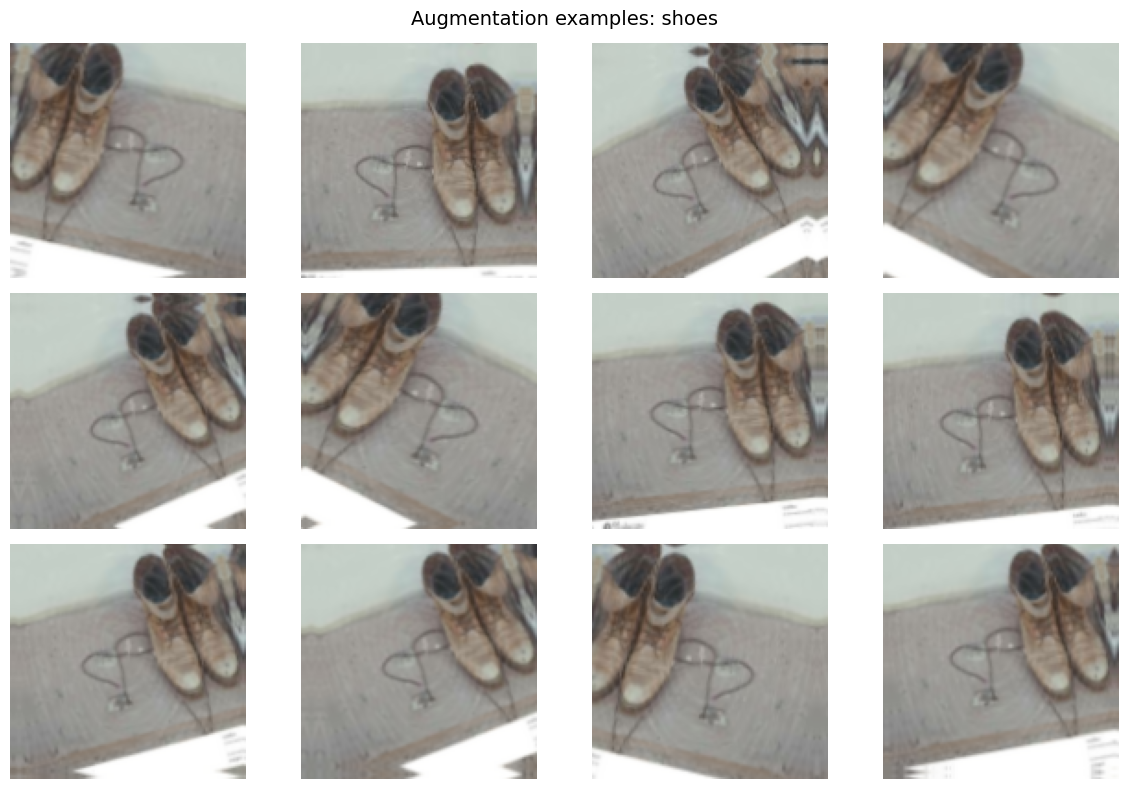

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/augmentation_examples.png


In [6]:
# Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=RANDOM_STATE),
        layers.RandomRotation(0.08, seed=RANDOM_STATE),
        layers.RandomZoom(0.10, seed=RANDOM_STATE),
        layers.RandomTranslation(0.05, 0.05, seed=RANDOM_STATE),
    ],
    name="data_augmentation",
)

# Visualize examples
sample_image = images[0]

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    augmented = data_augmentation(tf.expand_dims(sample_image, axis=0), training=True)
    ax.imshow(augmented[0])
    ax.axis("off")

fig.suptitle(f"Augmentation examples: {class_list[int(labels[0])]}", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "augmentation_examples.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## Class Weights
Attempt to compensate class imbalance: large 'clothes' class in relation to others.
- This does not change the validation/test distribution, it only affects the loss during training.

In [7]:
class_weights = get_class_weights(train_labels)

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{label:>2d} {class_list[label]:>15s}: {weight:.3f}")

Class weights:
 0         battery: 1.369
 1      biological: 1.313
 2     brown-glass: 2.129
 3       cardboard: 1.453
 4         clothes: 0.243
 5     green-glass: 2.052
 6           metal: 1.679
 7           paper: 1.231
 8         plastic: 1.496
 9           shoes: 0.654
10           trash: 1.854
11     white-glass: 1.667


## Build From Scratch DCNN
Small VGG-style CNN.

In [8]:
def build_scratch_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Smaller classifier head than Flatten().
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30, seed=RANDOM_STATE)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30, seed=RANDOM_STATE)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="scratch_cnn")

    return model

# Reproducibility: Clear old model state before creating a new model, reset seeds
keras.backend.clear_session()
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# Create Model
model = build_scratch_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
)

model.summary()

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,892 (1011.30 KB)

 Trainable params: 258,892 (1011.30 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Set Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    )
]

# Train Model
EPOCHS = 50

start_time = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
)
train_time = time.perf_counter() - start_time

print(f"Training time: {train_time:.2f}s")

Epoch 1/50


I0000 00:00:1779973250.174380   76432 cuda_dnn.cc:529] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.1885 - loss: 2.1155 - val_accuracy: 0.2895 - val_loss: 1.9414
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.3402 - loss: 1.8249 - val_accuracy: 0.3935 - val_loss: 1.6707
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4172 - loss: 1.6416 - val_accuracy: 0.4824 - val_loss: 1.4982
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4516 - loss: 1.5481 - val_accuracy: 0.5137 - val_loss: 1.3770
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4740 - loss: 1.4644 - val_accuracy: 0.4880 - val_loss: 1.4216
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5137 - loss: 1.4014 - val_accuracy: 0.5232 - val_loss: 1.3378
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5404 - loss: 1.3365 - val_accuracy: 0.4991 - val_loss: 1.3791
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5716 - loss: 1.2912 - val_accurac

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_accuracy.png


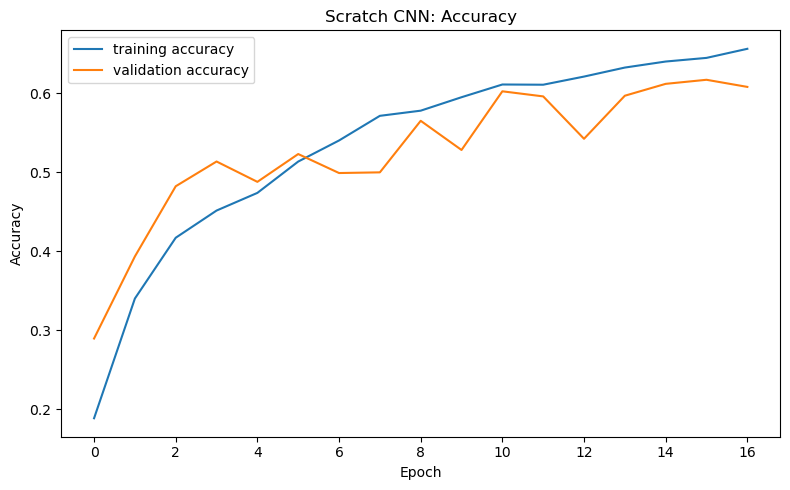

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_loss.png


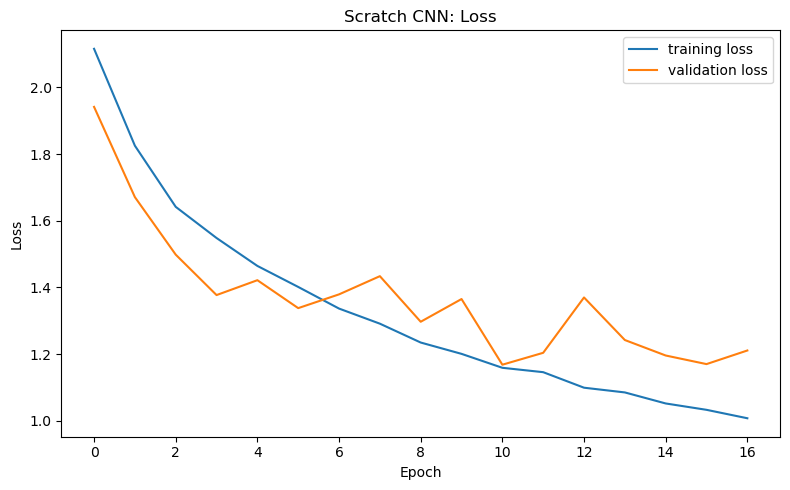

In [10]:
# Show training history plots
plot_training_history(history, title="Scratch CNN", save_dir=FIGURES_DIR/"scratch_CNN_training_history.png",)

In [11]:
# Save Training history scv for final evaluation

history_df = pd.DataFrame(history.history)

history_path = PROJECT_ROOT / "scratch_cnn" / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.head())

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.188507,2.115530,0.289519,1.941373
1,0.340179,1.824915,0.393471,1.670711
2,0.417165,1.641570,0.482388,1.498242
3,0.451607,1.548123,0.513746,1.376995
4,0.473985,1.464422,0.487972,1.421606


340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Scratch CNN
-----------
Training time     : 175.36s
Inference time    : 4.159s
Time per sample   : 1.787ms
-----------
              precision    recall  f1-score   support

     battery     0.4332    0.7535    0.5501       142
  biological     0.6000    0.7297    0.6585       148
 brown-glass     0.8734    0.7582    0.8118        91
   cardboard     0.8661    0.7239    0.7886       134
     clothes     0.8486    0.7647    0.8045       799
 green-glass     0.7692    0.9574    0.8531        94
       metal     0.3492    0.1913    0.2472       115
       paper     0.3188    0.7898    0.4542       157
     plastic     0.4500    0.4846    0.4667       130
       shoes     0.6486    0.1616    0.2588       297
       trash     0.4788    0.7524    0.5852       105
 white-glass     0.5000    0.1810    0.2658       116

    accuracy                         0.6181      2328
   macro avg     0.5947    0.6040    0.56

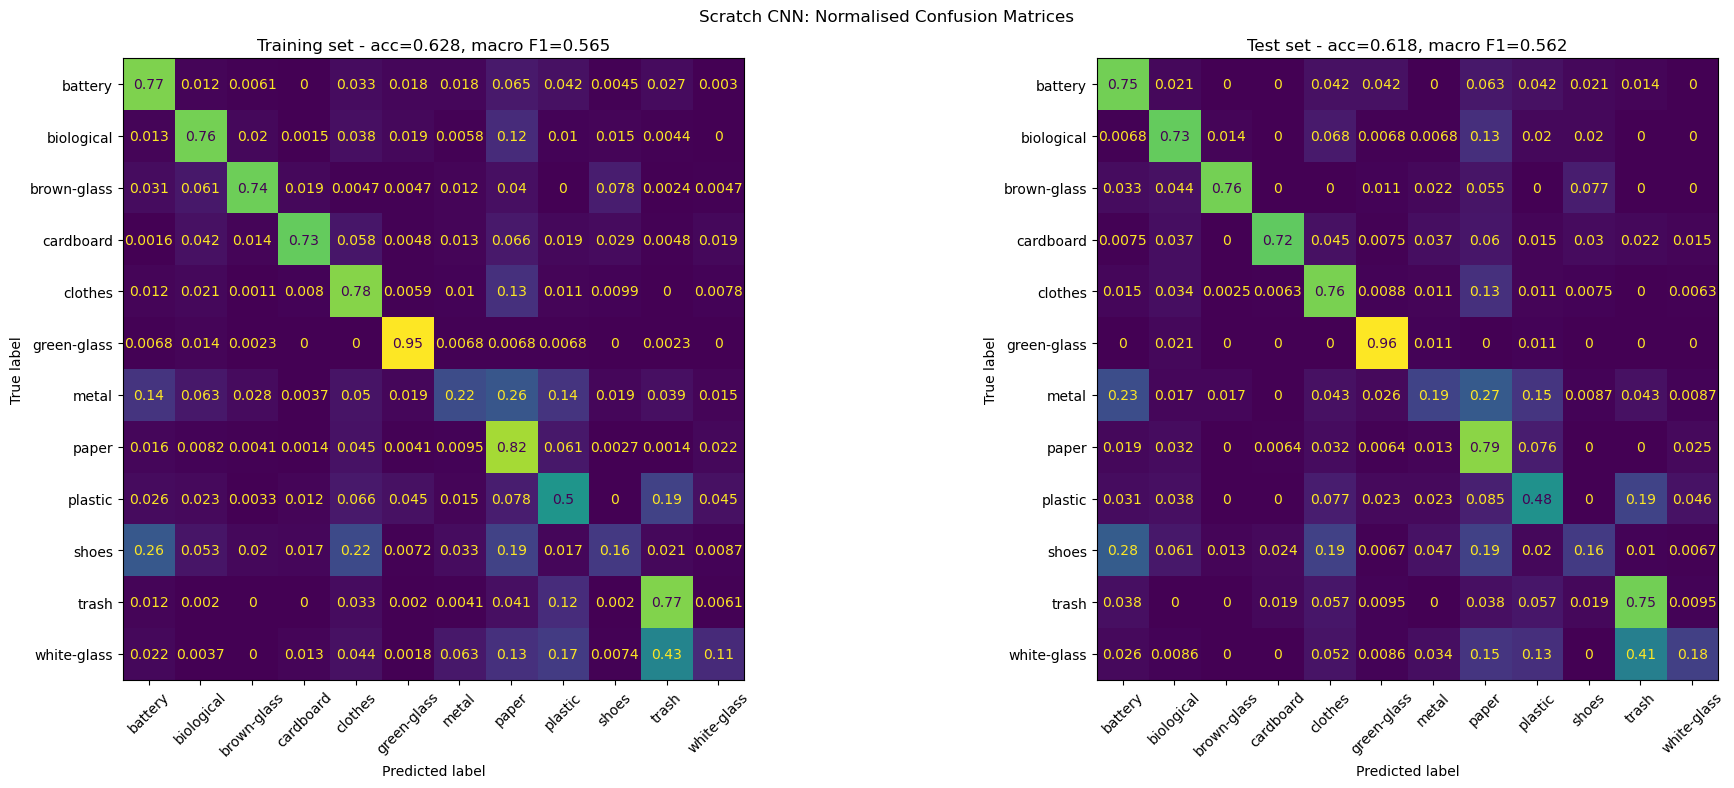

Saved metrics to: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_metrics.json


In [12]:
# Evaluate on training and test sets
start_time = time.perf_counter()

train_prob = model.predict(train_eval_ds)
test_prob = model.predict(test_ds)

inference_time = time.perf_counter() - start_time

train_pred = np.argmax(train_prob, axis=1)
test_pred = np.argmax(test_prob, axis=1)

metrics = eval_model(
    test_labels,
    test_pred,
    class_list,
    model_name="Scratch CNN",
    y_train=train_labels,
    train_pred=train_pred,
    train_time=train_time,
    inference_time=inference_time,
    save_path=FIGURES_DIR/"scratch_cnn_confusion_matrices.png",
)

save_metrics(
    metrics,
    PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_metrics.json",
)

## Save Predictions

In [13]:
predictions_df = pd.DataFrame({
    "path": test_paths,
    "true_label": test_labels,
    "true_class": [class_list[i] for i in test_labels],
    "pred_label": test_pred,
    "pred_class": [class_list[i] for i in test_pred],
    "confidence": np.max(test_prob, axis=1),
    "correct": test_labels == test_pred,
})

predictions_path = PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved:", predictions_path)
display(predictions_df.head())

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_predictions.csv


,path,true_label,true_class,pred_label,pred_class,confidence,correct
0,/home/n11902736/cab420/WasteClassification/dat...,0,battery,0,battery,0.819020,True
1,/home/n11902736/cab420/WasteClassification/dat...,0,battery,0,battery,0.776224,True
2,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,0,battery,0.807098,False
3,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,4,clothes,0.668219,True
4,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,0,battery,0.922689,False


## Analysis: High confidence misclassification

In [14]:
wrong_df = predictions_df[predictions_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(12))

,path,true_label,true_class,pred_label,pred_class,confidence,correct
1345,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,1,biological,0.992820,False
2039,/home/n11902736/cab420/WasteClassification/dat...,3,cardboard,7,paper,0.985745,False
1871,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,7,paper,0.983291,False
314,/home/n11902736/cab420/WasteClassification/dat...,2,brown-glass,1,biological,0.981533,False
1878,/home/n11902736/cab420/WasteClassification/dat...,0,battery,5,green-glass,0.981429,False
25,/home/n11902736/cab420/WasteClassification/dat...,6,metal,2,brown-glass,0.974117,False
2063,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,4,clothes,0.972183,False
2106,/home/n11902736/cab420/WasteClassification/dat...,2,brown-glass,1,biological,0.970798,False
836,/home/n11902736/cab420/WasteClassification/dat...,0,battery,7,paper,0.963801,False
1616,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,5,green-glass,0.963211,False


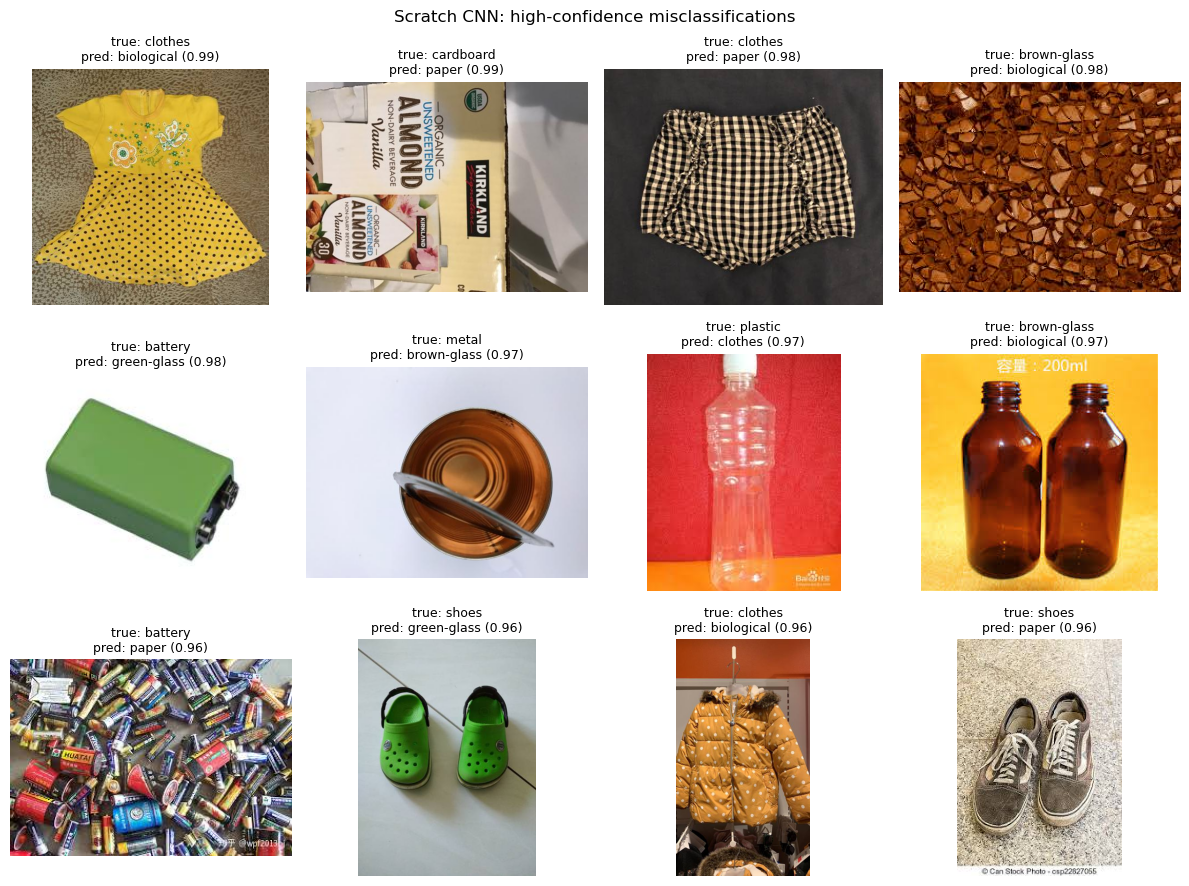

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_cnn_high_confidence_errors.png


In [15]:
# Plot examples
top_k = 12
failure_df = wrong_df.head(top_k)

n_cols = 4
n_rows = int(np.ceil(len(failure_df) / n_cols))

fig = plt.figure(figsize=(12, 3 * n_rows))

for plot_i, (_, row) in enumerate(failure_df.iterrows()):
    ax = fig.add_subplot(n_rows, n_cols, plot_i + 1)

    img = plt.imread(row["path"])
    ax.imshow(img)

    ax.set_title(
        f"true: {row['true_class']}\n"
        f"pred: {row['pred_class']} ({row['confidence']:.2f})",
        fontsize=9,
    )

    ax.axis("off")

fig.suptitle("Scratch CNN: high-confidence misclassifications", fontsize=12)
plt.tight_layout()

figure_path = FIGURES_DIR / "scratch_cnn_high_confidence_errors.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)